# Module 08 — Trajectory & Pseudotime Analysis

This notebook visualizes pre-computed trajectory and pseudotime results from
`scripts/08_trajectory.py`. PAGA (Partition-based Graph Abstraction) is used
to infer cell state transitions, and diffusion pseudotime (DPT) orders cells
along differentiation/degeneration trajectories.

**Data sources:**
- `results/trajectories/paga_*.png` — PAGA connectivity graphs
- `results/trajectories/pseudotime_by_condition_*.png` — Pseudotime distributions
- `results/trajectories/pseudotime_by_celltype_*.png` — Cell type ordering
- `results/trajectories/gene_dynamics_*.png` — Gene expression over pseudotime
- `results/trajectories/pseudotime_correlations_*.tsv` — Statistical tests
- `results/trajectories/trajectory_genes_*.tsv` — Genes correlated with pseudotime

In [1]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display, Markdown

plt.rcParams.update({'figure.dpi': 120, 'savefig.dpi': 200, 'savefig.bbox': 'tight'})

# ── Paths ──────────────────────────────────────────────────────────────────
BASE = Path('..').resolve()
RESULTS = BASE / 'results' / 'trajectories'

print(f'Results directory: {RESULTS}')
print(f'PNG files: {len(list(RESULTS.glob("*.png")))}')
print(f'TSV files: {len(list(RESULTS.glob("*.tsv")))}')

Results directory: /home/ubuntu/lotz-ivd/results/trajectories
PNG files: 15
TSV files: 12


## Pseudotime-Condition Correlations

Spearman correlation between pseudotime and condition (encoded as ordinal:
healthy < mild < severe). A negative correlation means degenerated cells
occupy earlier pseudotime positions; a positive correlation means degenerated
cells are at later positions.

In [2]:
# Load and display correlation results for each compartment
compartments = ['NP', 'AF', 'CEP']

all_corrs = []
for comp in compartments:
    corr_path = RESULTS / f'pseudotime_correlations_{comp}.tsv'
    if corr_path.exists():
        df = pd.read_csv(corr_path, sep='\t')
        if 'compartment' not in df.columns:
            df.insert(0, 'compartment', comp)
        else:
            df['compartment'] = comp
        all_corrs.append(df)

if all_corrs:
    corr_df = pd.concat(all_corrs, ignore_index=True)
    display(corr_df.style.set_caption('Pseudotime-Condition Correlations by Compartment'))
else:
    print('No correlation files found')

,compartment,embedding,test,rho,pvalue,n,statistic,n_healthy,n_degen,median_healthy,median_degen
0,NP,scVI_mesenchymal,pseudotime_vs_condition_ordinal,-0.151025,0.000000,50000.000000,nan,nan,nan,nan,nan
1,NP,scVI_mesenchymal,pseudotime_healthy_vs_degenerated,nan,0.000073,nan,217706720.000000,16091.000000,26454.000000,0.046621,0.046122
2,NP,scVI_mesenchymal,pseudotime_vs_condition_NP_fibrocartilaginous,0.192515,0.000000,16403.000000,nan,nan,nan,nan,nan
3,NP,scVI_mesenchymal,pseudotime_vs_condition_NP_mature_chondrocyte,-0.207246,0.000000,26957.000000,nan,nan,nan,nan,nan
4,NP,scVI_mesenchymal,pseudotime_vs_condition_NP_notochordal,-0.282847,0.000000,4597.000000,nan,nan,nan,nan,nan
5,NP,scVI_mesenchymal,pseudotime_vs_condition_NP_stressed_degen,-0.321906,0.000000,2043.000000,nan,nan,nan,nan,nan
6,AF,scVI_mesenchymal,pseudotime_vs_condition_ordinal,0.324608,0.000000,50000.000000,nan,nan,nan,nan,nan
7,AF,scVI_mesenchymal,pseudotime_healthy_vs_degenerated,nan,0.000000,nan,192129376.000000,29430.000000,20570.000000,0.408327,0.494469
8,AF,scVI_mesenchymal,pseudotime_vs_condition_AF_inner,-0.314703,0.000000,11967.000000,nan,nan,nan,nan,nan
9,AF,scVI_mesenchymal,pseudotime_vs_condition_AF_outer,0.118275,0.000000,29318.000000,nan,nan,nan,nan,nan


## PAGA Connectivity Graphs

PAGA shows the connectivity between cell type clusters in the trajectory graph.
Edge thickness represents the strength of connection, revealing which cell
states are transcriptionally adjacent.

### NP — PAGA Graph

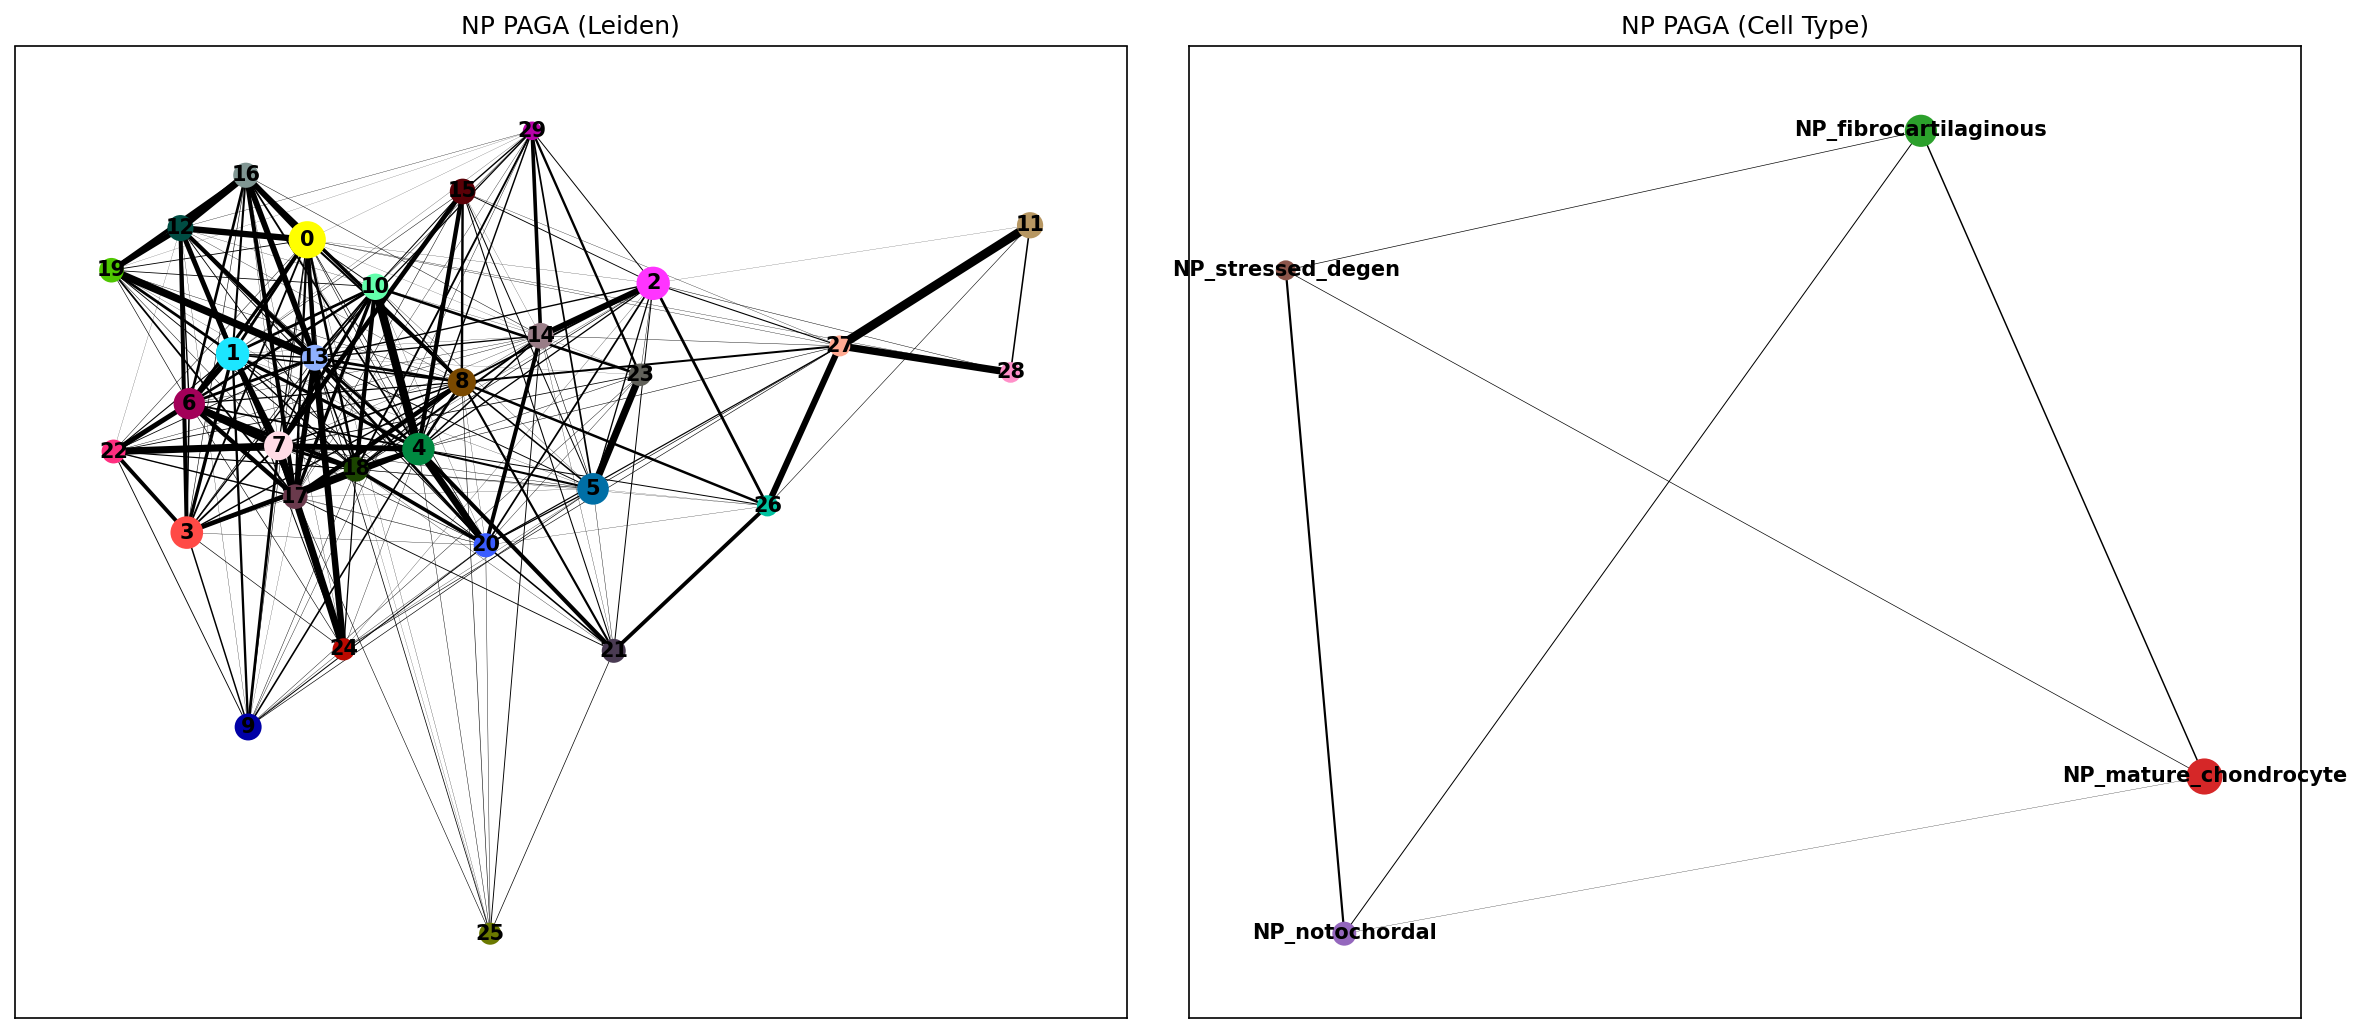

### AF — PAGA Graph

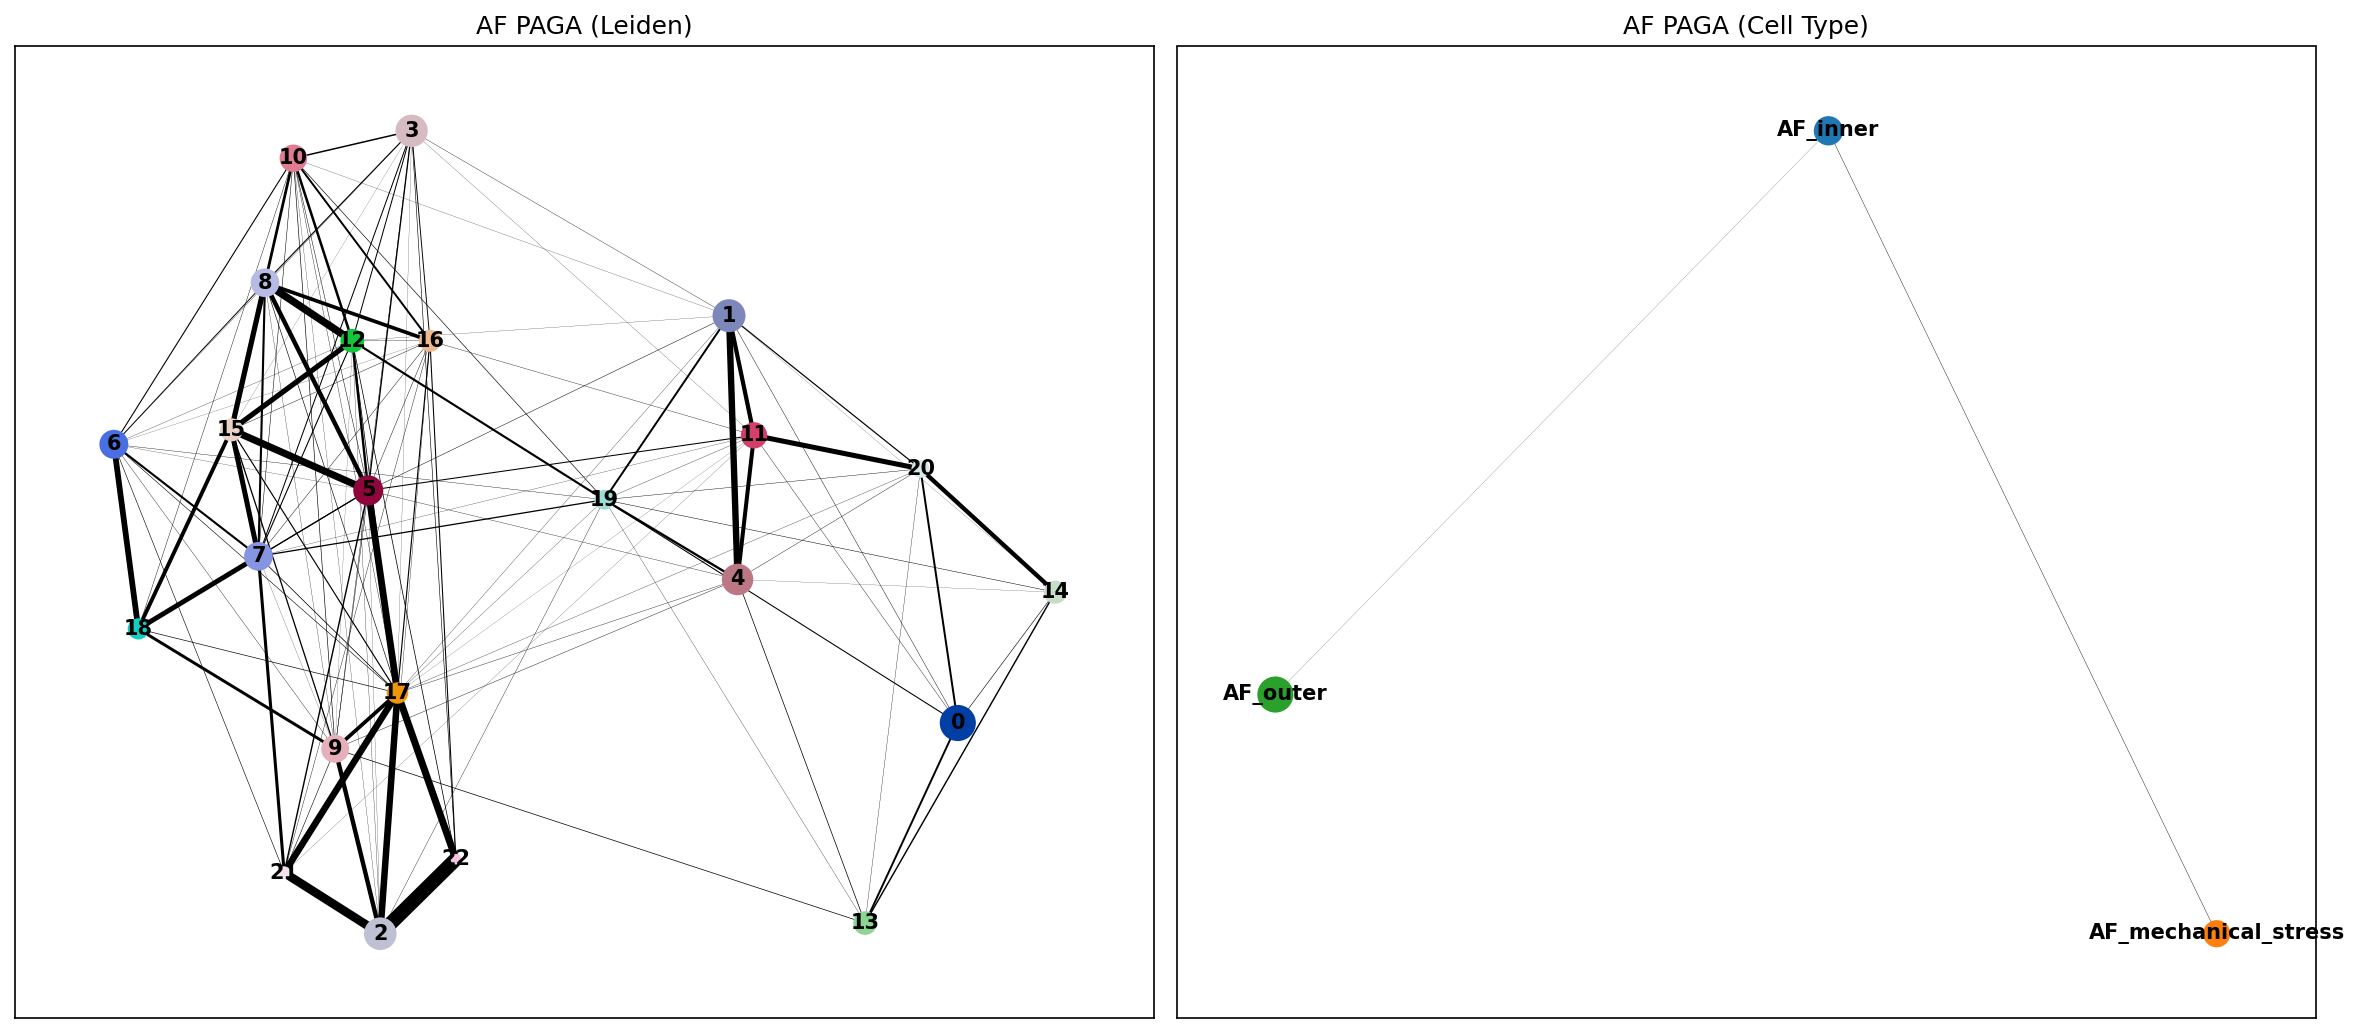

### CEP — PAGA Graph

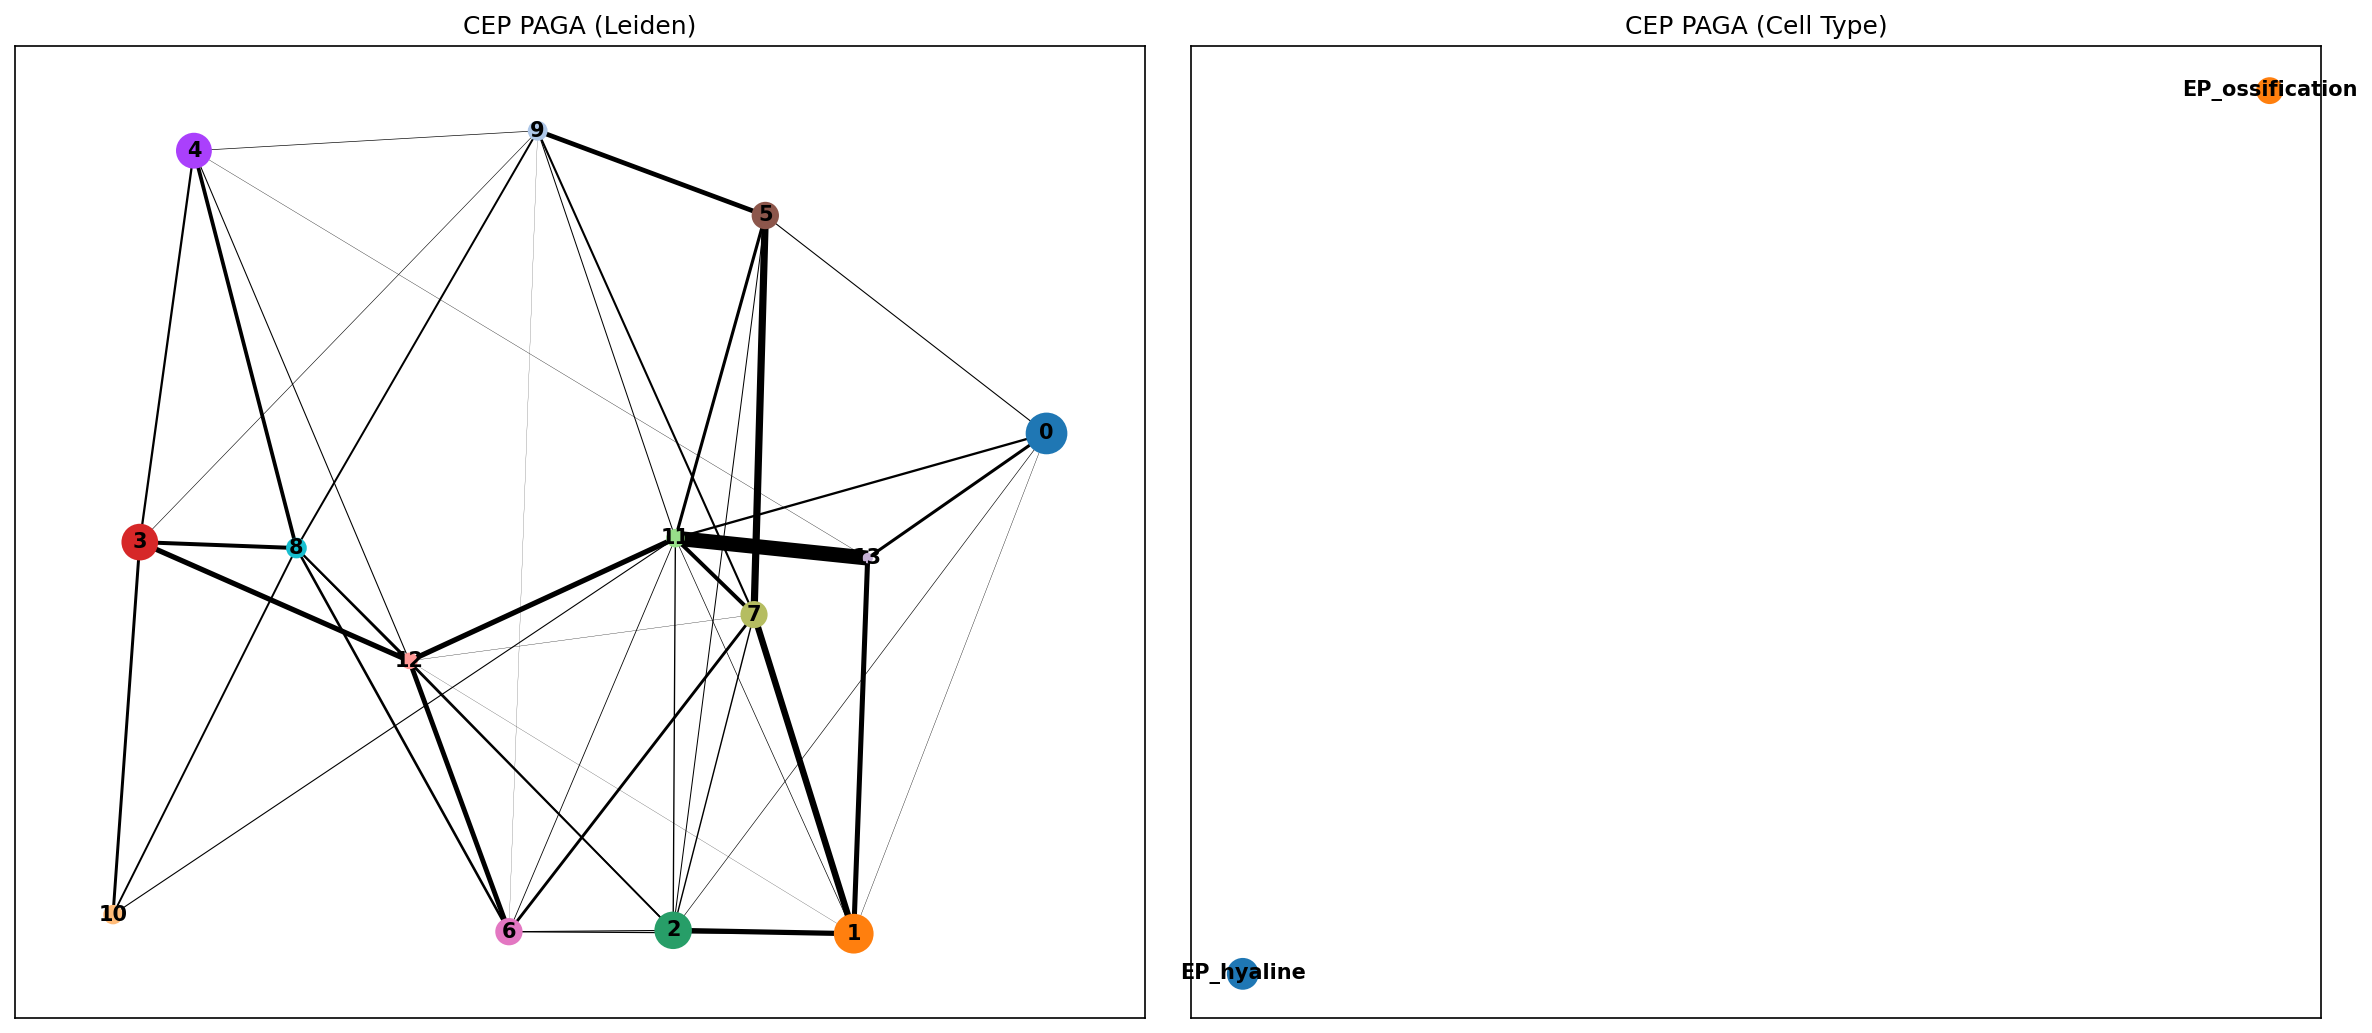

In [3]:
for comp in compartments:
    paga_path = RESULTS / f'paga_{comp}.png'
    if paga_path.exists():
        display(Markdown(f'### {comp} — PAGA Graph'))
        display(Image(filename=str(paga_path), width=700))
    else:
        print(f'PAGA plot not found for {comp}')

## Pseudotime by Condition

Distribution of pseudotime values for each condition (healthy, mild degeneration,
severe degeneration). Shifts in the distribution indicate trajectory position
changes with disease.

### NP — Pseudotime by Condition

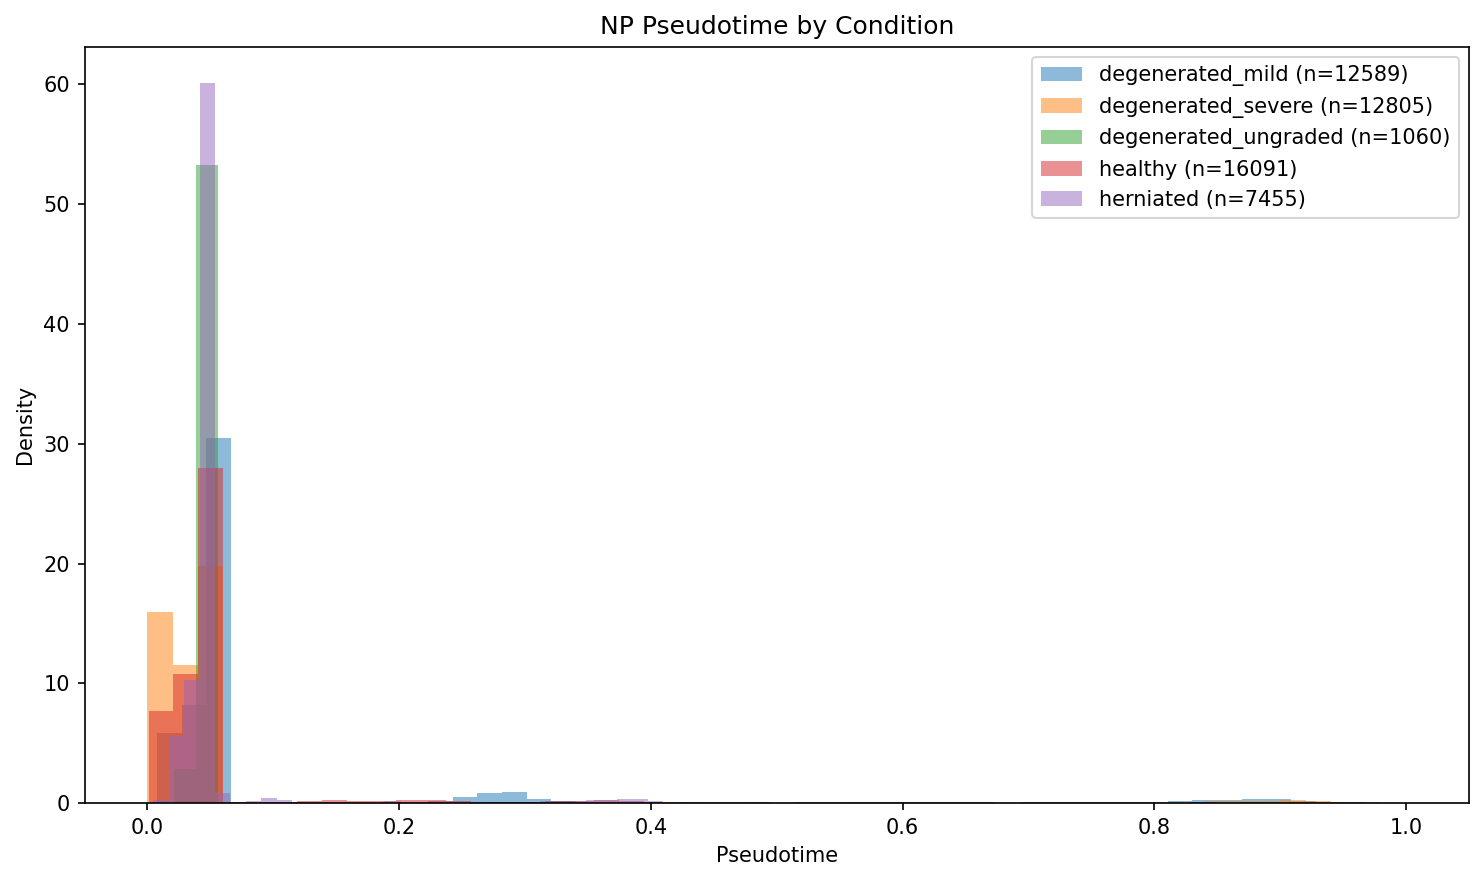

### AF — Pseudotime by Condition

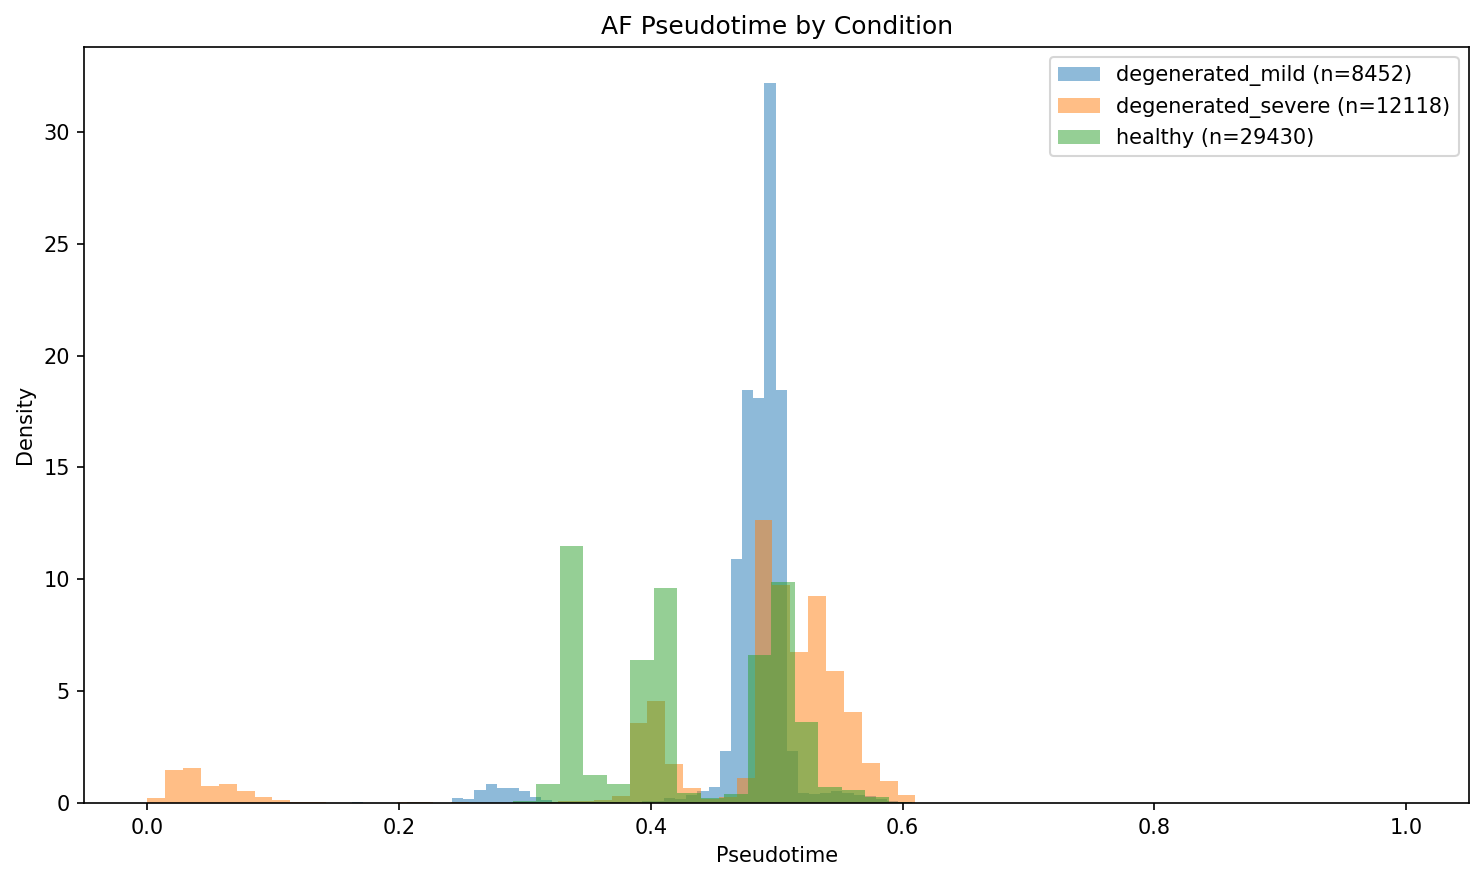

### CEP — Pseudotime by Condition

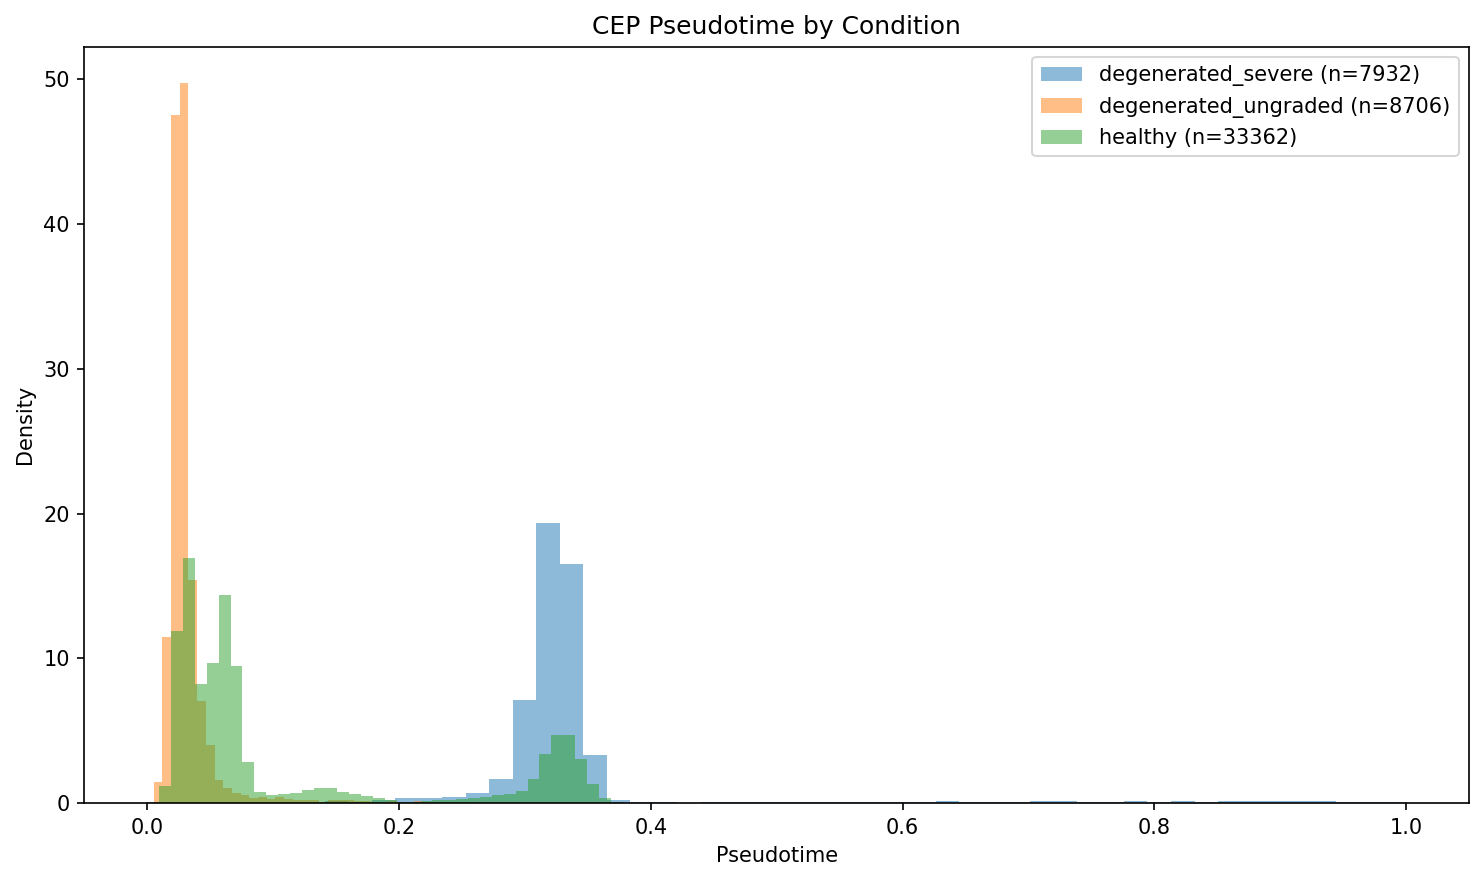

In [4]:
for comp in compartments:
    pt_cond_path = RESULTS / f'pseudotime_by_condition_{comp}.png'
    if pt_cond_path.exists():
        display(Markdown(f'### {comp} — Pseudotime by Condition'))
        display(Image(filename=str(pt_cond_path), width=700))
    else:
        print(f'Pseudotime by condition plot not found for {comp}')

## Pseudotime by Cell Type

Pseudotime ordering across cell types within each compartment. This reveals
the progression from one cell state to another along the trajectory.

### NP — Pseudotime by Cell Type

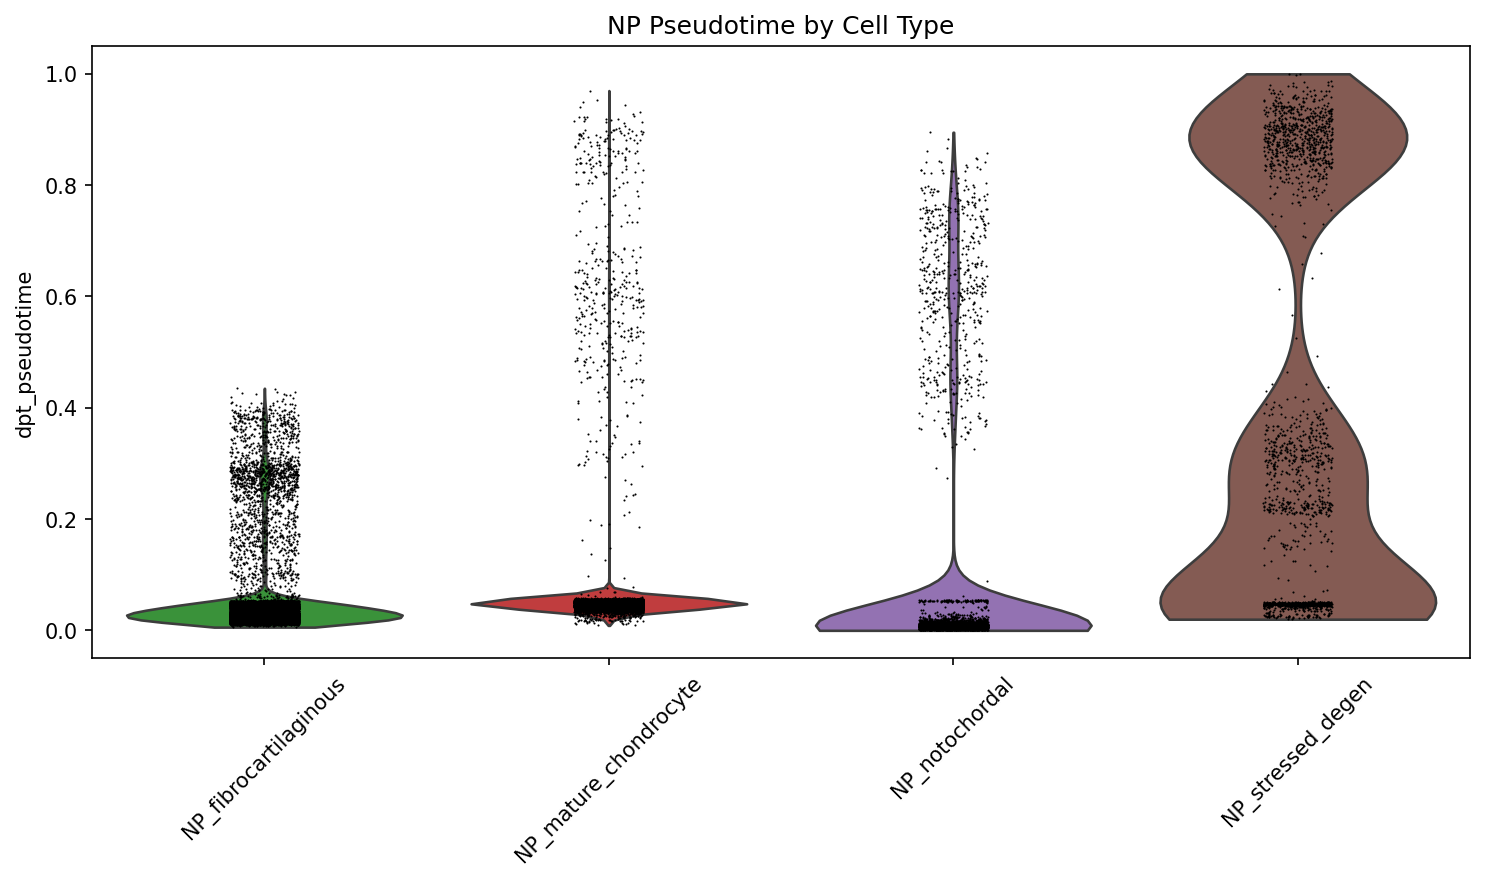

### AF — Pseudotime by Cell Type

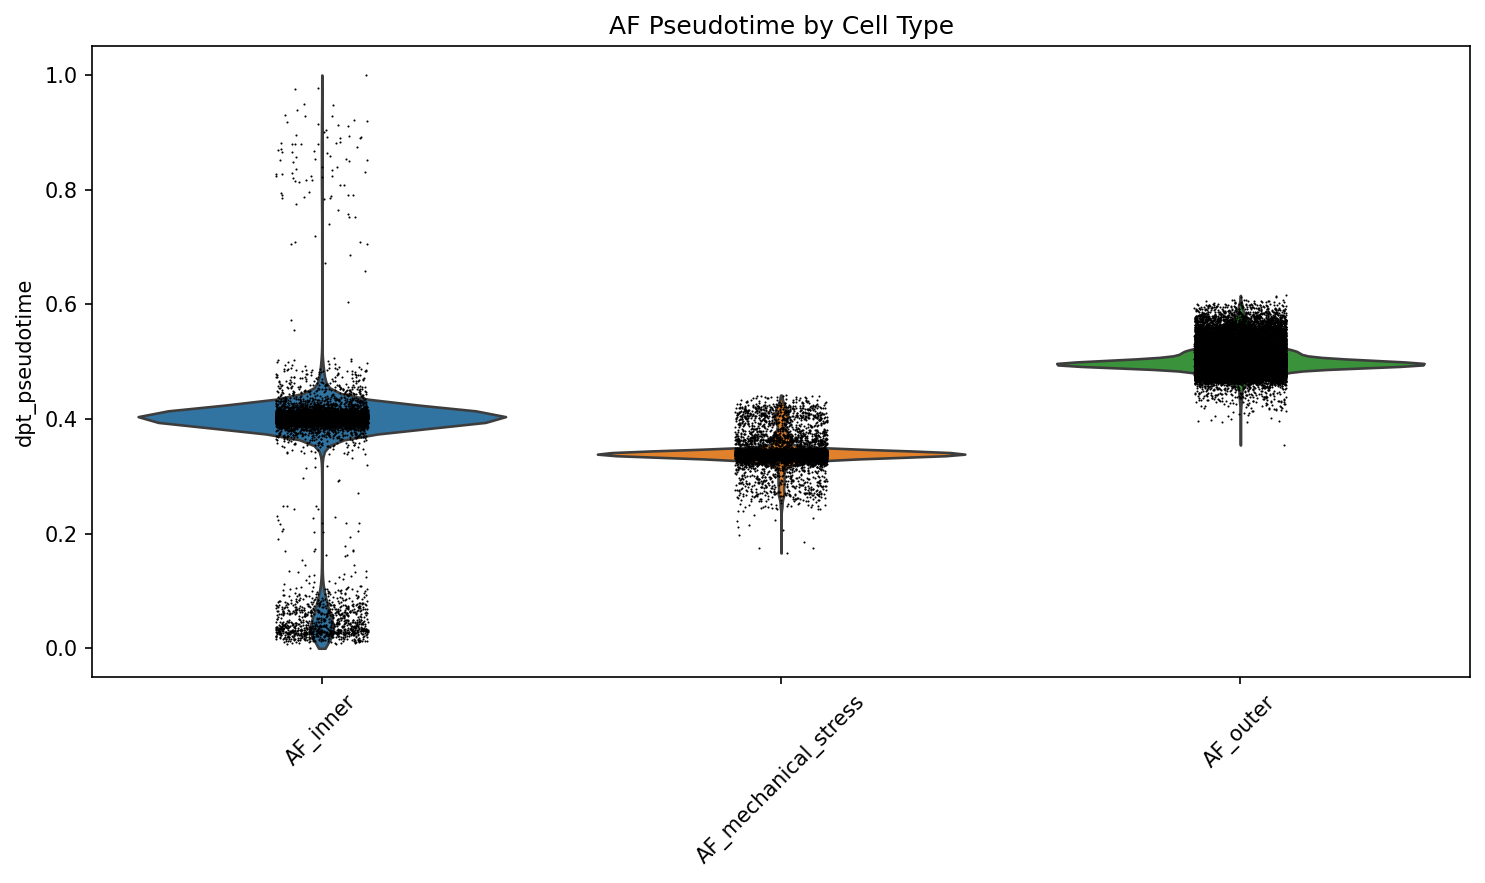

### CEP — Pseudotime by Cell Type

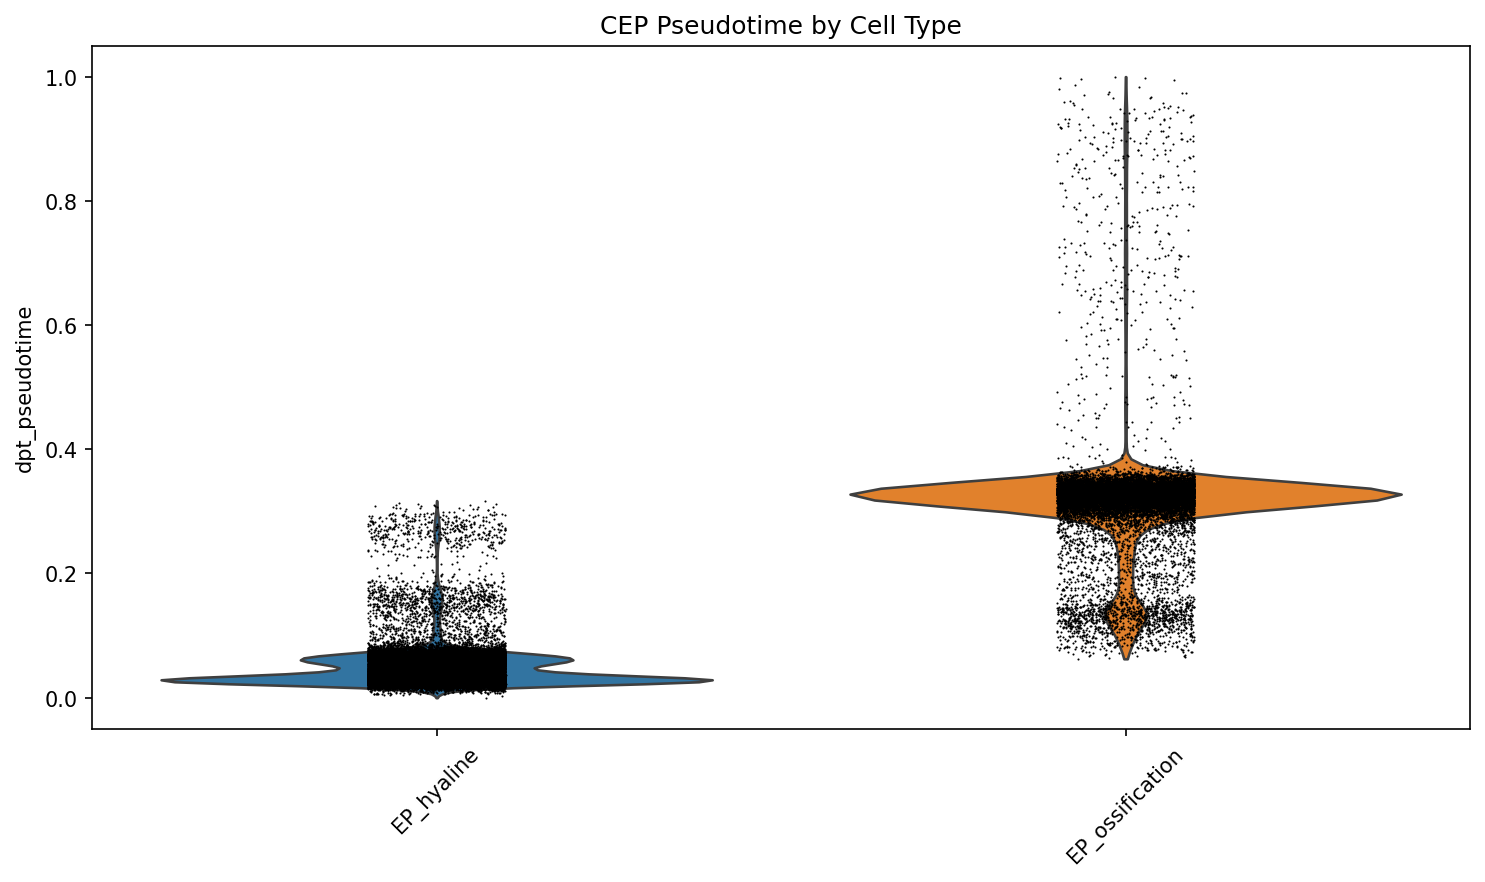

In [5]:
for comp in compartments:
    pt_ct_path = RESULTS / f'pseudotime_by_celltype_{comp}.png'
    if pt_ct_path.exists():
        display(Markdown(f'### {comp} — Pseudotime by Cell Type'))
        display(Image(filename=str(pt_ct_path), width=700))
    else:
        print(f'Pseudotime by cell type plot not found for {comp}')

## Gene Dynamics Along Pseudotime

Expression of key genes plotted as a function of pseudotime. These show how
marker gene expression changes along the trajectory, highlighting the genes
that drive cell state transitions.

### NP — Gene Dynamics

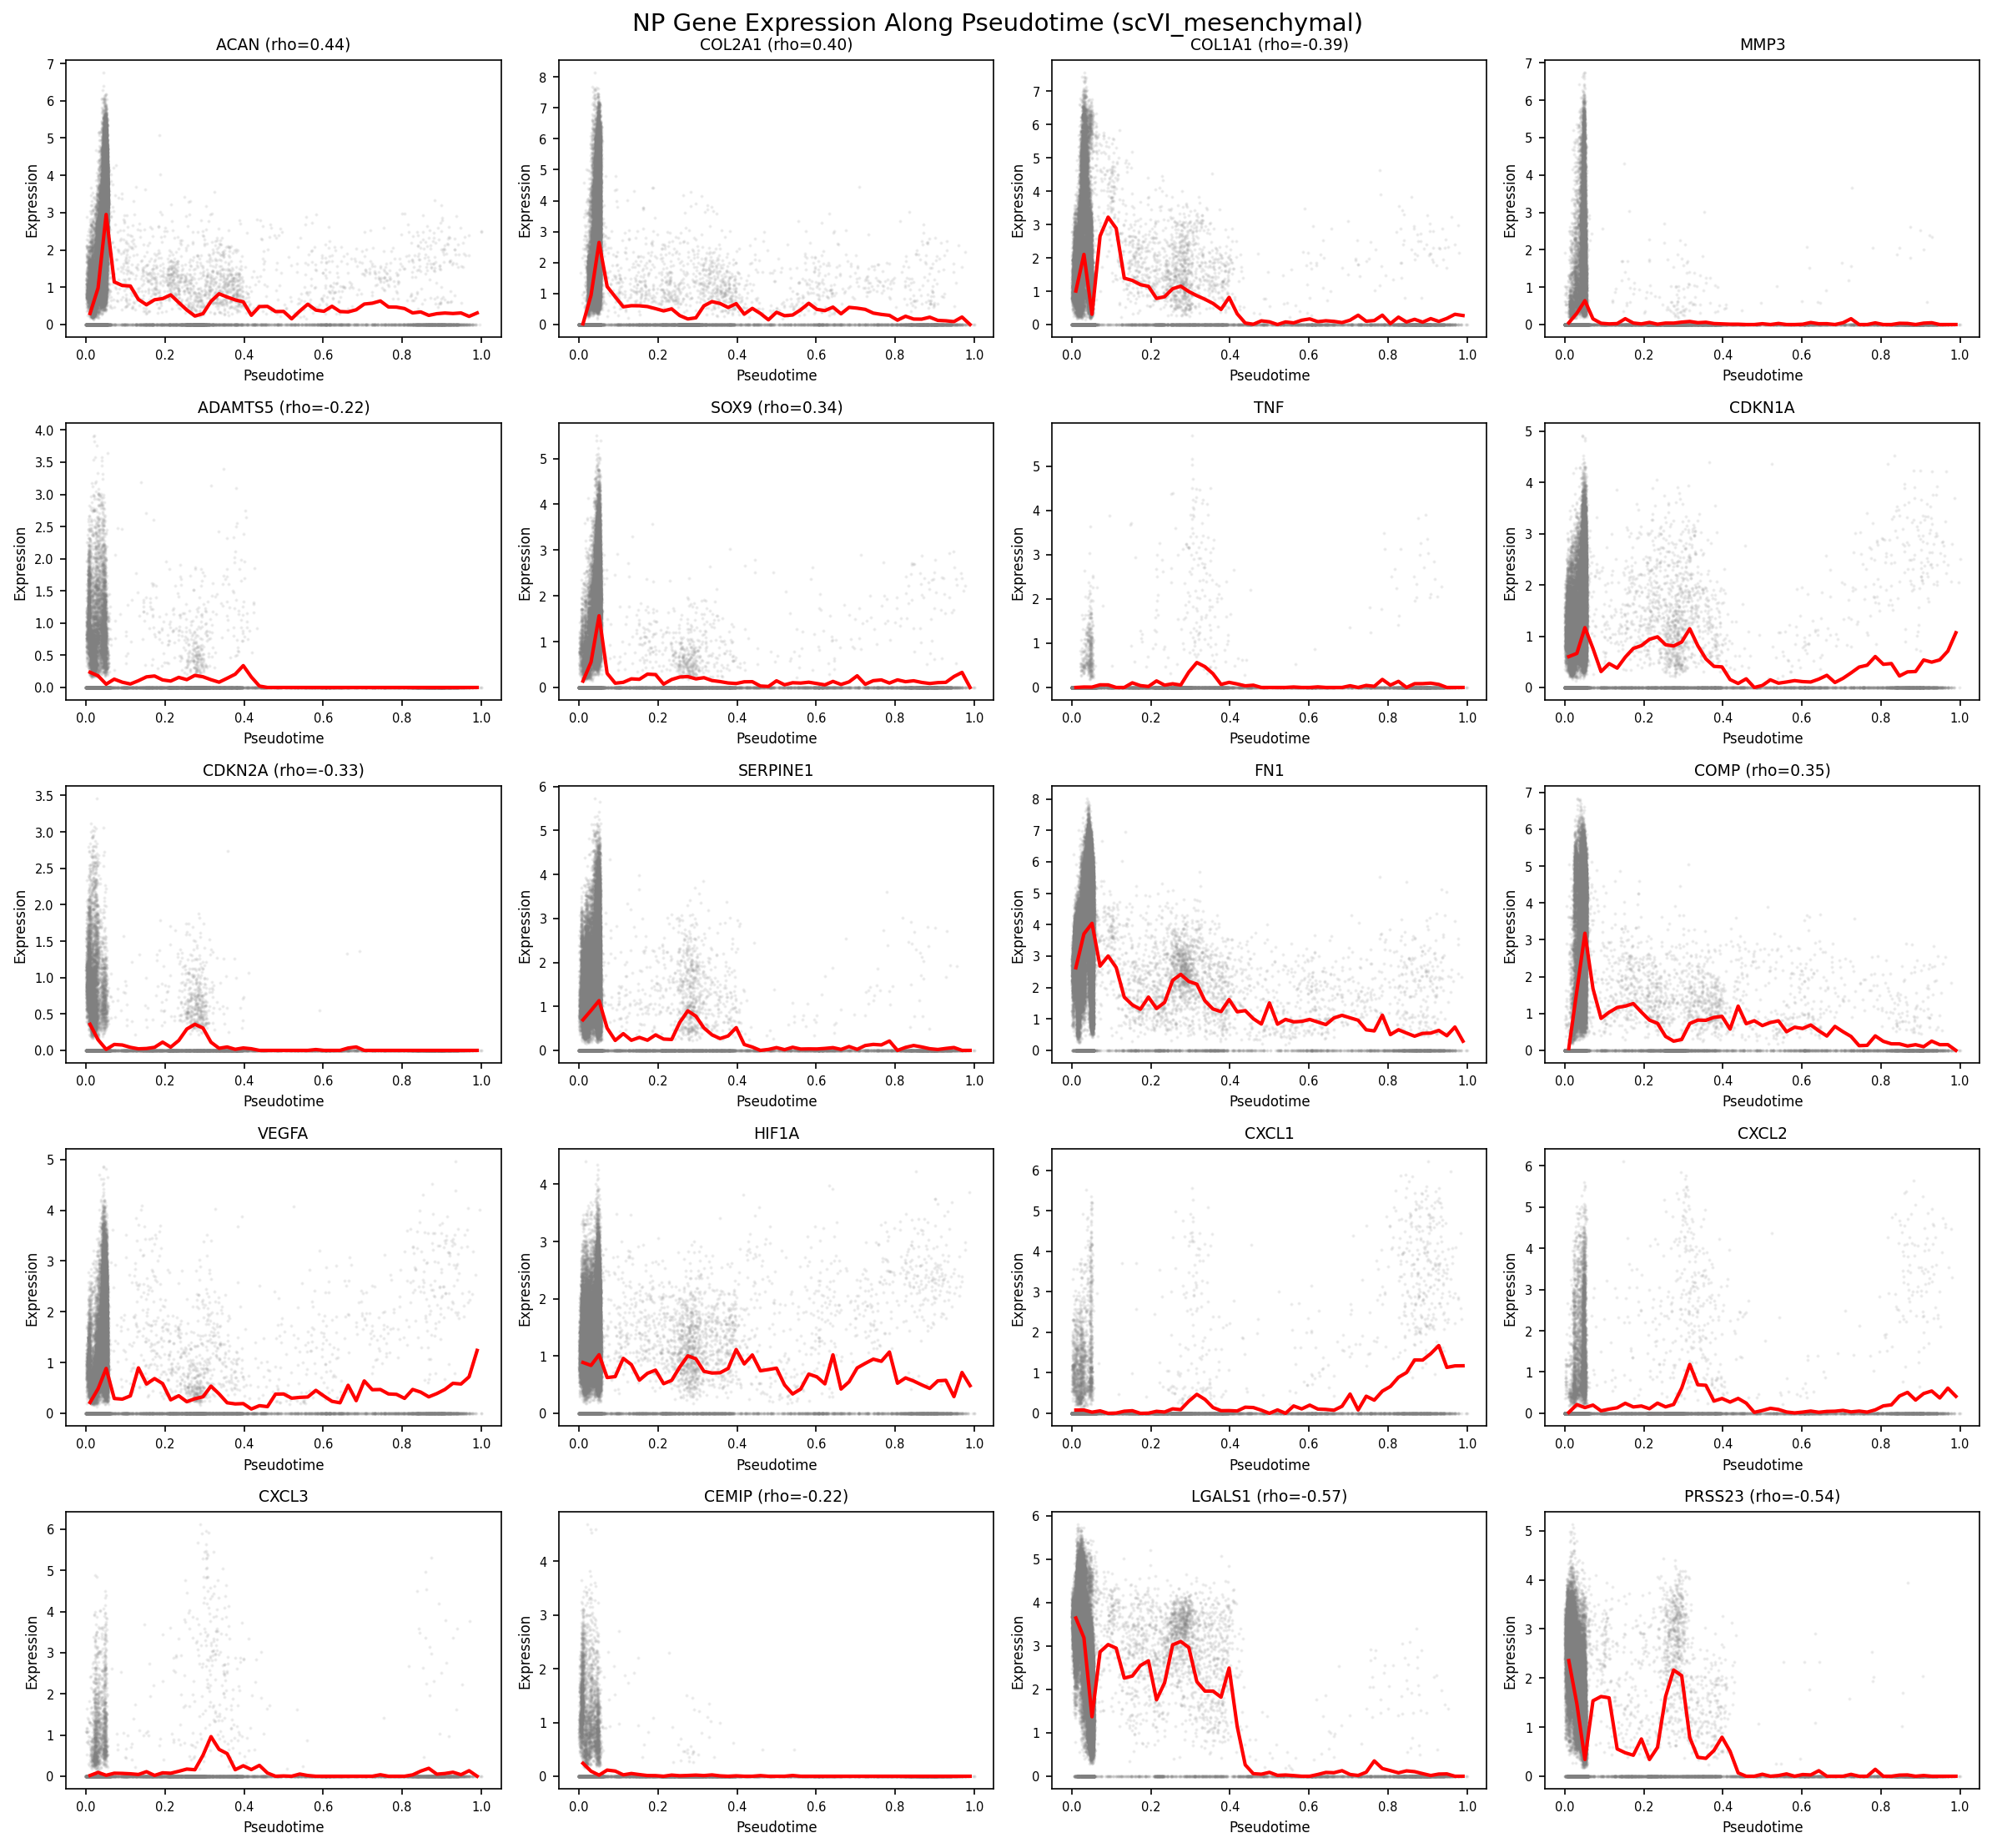

### AF — Gene Dynamics

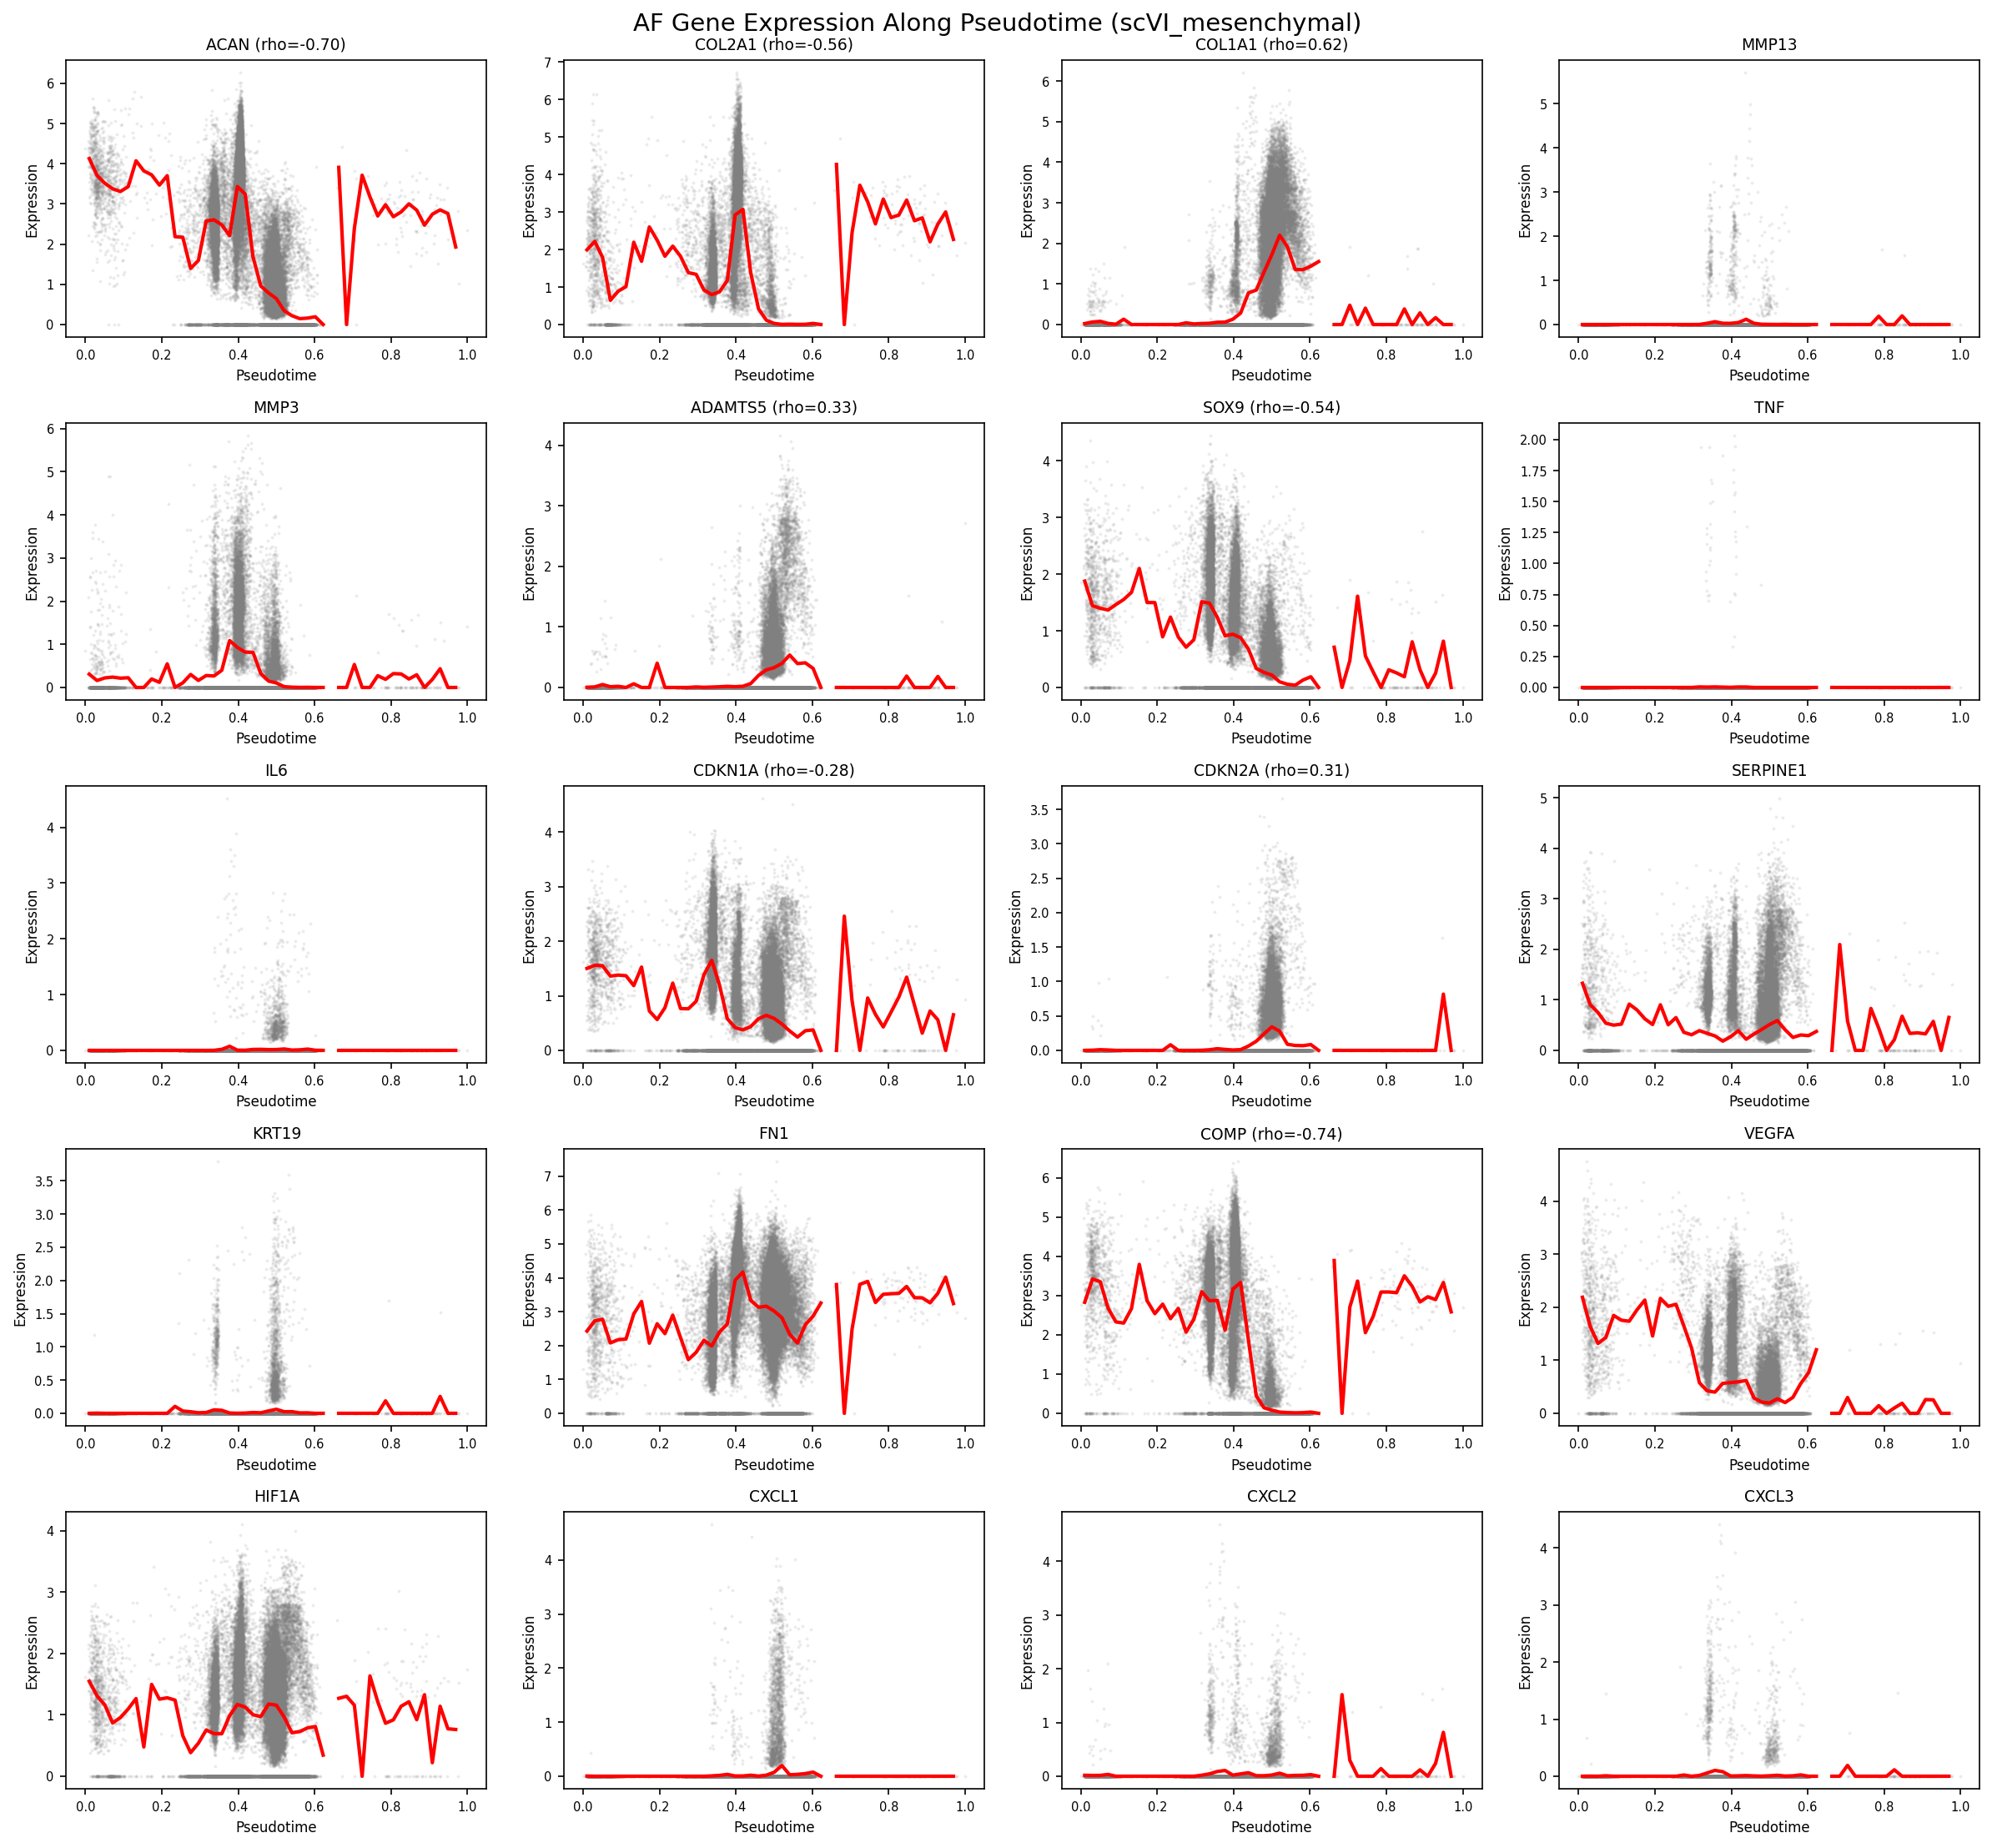

### CEP — Gene Dynamics

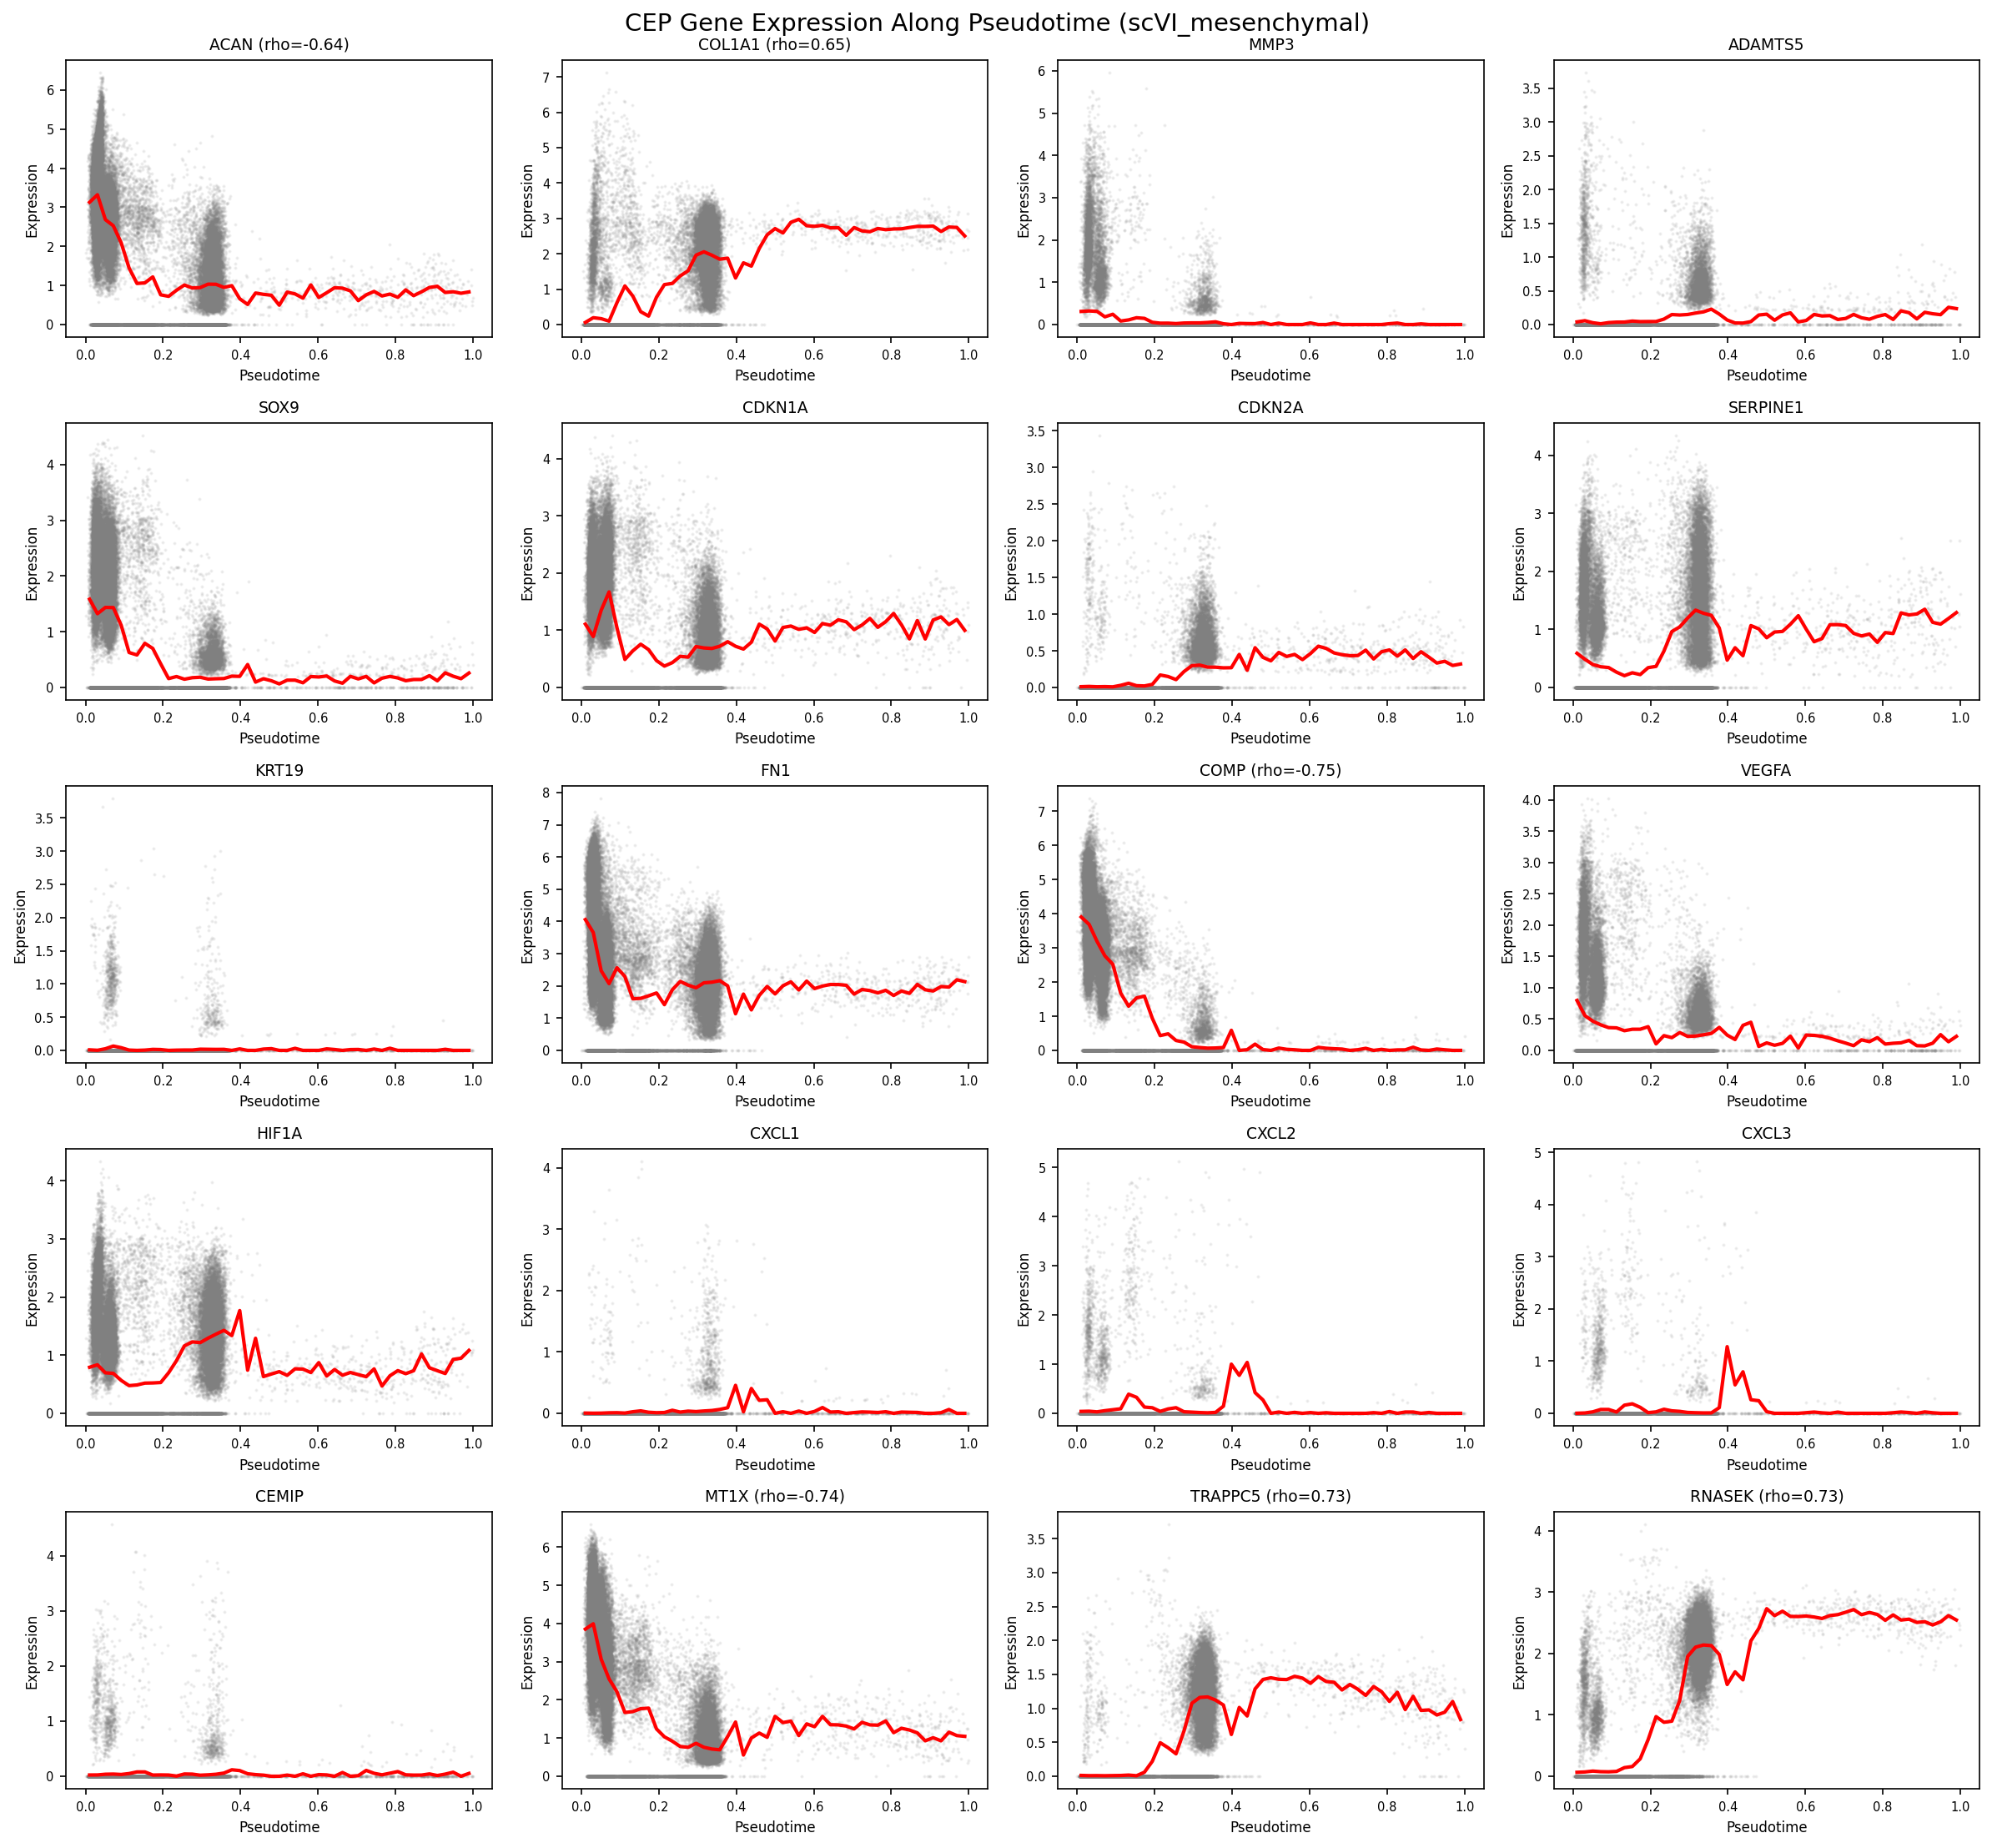

In [6]:
for comp in compartments:
    gene_path = RESULTS / f'gene_dynamics_{comp}.png'
    if gene_path.exists():
        display(Markdown(f'### {comp} — Gene Dynamics'))
        display(Image(filename=str(gene_path), width=800))
    else:
        print(f'Gene dynamics plot not found for {comp}')

## Trajectory-Associated Genes

Genes most strongly correlated with pseudotime in each compartment. These
are candidate drivers of the degeneration trajectory.

In [7]:
for comp in compartments:
    tg_path = RESULTS / f'trajectory_genes_{comp}.tsv'
    if tg_path.exists():
        tg = pd.read_csv(tg_path, sep='\t')
        display(Markdown(f'### {comp} — Top Trajectory Genes'))
        print(f'Total trajectory genes: {len(tg)}')
        display(tg.head(20).style.set_caption(f'{comp}: Top 20 Trajectory-Associated Genes'))
    else:
        print(f'Trajectory genes file not found for {comp}')

### NP — Top Trajectory Genes

Total trajectory genes: 500


,gene,rho,pvalue,padj,program
0,LGALS1,-0.572581,0.000000,0.000000,late_down
1,PRSS23,-0.538161,0.000000,0.000000,late_down
2,RNASEK,-0.536304,0.000000,0.000000,late_down
3,TMSB10,-0.508121,0.000000,0.000000,late_down
4,VIM,-0.505000,0.000000,0.000000,late_down
5,C12orf75,-0.491003,0.000000,0.000000,late_down
6,S100A6,-0.481762,0.000000,0.000000,late_down
7,THY1,-0.480425,0.000000,0.000000,late_down
8,FTH1,-0.477001,0.000000,0.000000,late_down
9,TMSB4X,-0.474276,0.000000,0.000000,late_down


### AF — Top Trajectory Genes

Total trajectory genes: 500


,gene,rho,pvalue,padj,program
0,FGFBP2,-0.808125,0.000000,0.000000,late_down
1,SERPINA1,-0.777296,0.000000,0.000000,late_down
2,COMP,-0.735611,0.000000,0.000000,late_down
3,PRELP,-0.729467,0.000000,0.000000,late_down
4,MT1G,-0.722981,0.000000,0.000000,late_down
5,MGP,-0.711528,0.000000,0.000000,late_down
6,MT1X,-0.709626,0.000000,0.000000,late_down
7,ACAN,-0.703318,0.000000,0.000000,late_down
8,CYTL1,-0.700572,0.000000,0.000000,late_down
9,APOD,-0.697720,0.000000,0.000000,late_down


### CEP — Top Trajectory Genes

Total trajectory genes: 500


,gene,rho,pvalue,padj,program
0,COMP,-0.753051,0.000000,0.000000,late_down
1,MT1X,-0.736568,0.000000,0.000000,late_down
2,TRAPPC5,0.730292,0.000000,0.000000,late_up
3,RNASEK,0.730228,0.000000,0.000000,late_up
4,CLU,-0.729213,0.000000,0.000000,late_down
5,EEF1G,0.727059,0.000000,0.000000,late_up
6,NME2,0.718154,0.000000,0.000000,late_up
7,FTH1,0.715367,0.000000,0.000000,late_up
8,NEK10,0.715361,0.000000,0.000000,late_up
9,ATP6V0C,0.714361,0.000000,0.000000,late_up


## Overlap with Differential Expression

Trajectory-associated genes that also appear in the pseudobulk DE results
from Module 06. This overlap strengthens confidence in both analyses.

In [8]:
for comp in compartments:
    overlap_path = RESULTS / f'trajectory_de_overlap_{comp}.tsv'
    if overlap_path.exists():
        overlap = pd.read_csv(overlap_path, sep='\t')
        display(Markdown(f'### {comp} — Trajectory-DE Overlap'))
        print(f'Overlapping genes: {len(overlap)}')
        if len(overlap) > 0:
            display(overlap.head(20).style.set_caption(
                f'{comp}: Genes in Both Trajectory and DE Analyses'))
    else:
        print(f'Trajectory-DE overlap file not found for {comp}')

### NP — Trajectory-DE Overlap

Overlapping genes: 124


,gene,rho,pvalue,padj_x,program,cell_type,comparison,log2FC,padj_y
0,TMSB4X,-0.474276,0.000000,0.000000,late_down,NP_mature_chondrocyte,healthy_vs_degenerated_severe,1.656753,0.044572
1,TMSB4X,-0.474276,0.000000,0.000000,late_down,NP_mature_chondrocyte,mild_vs_severe,1.078505,0.034871
2,CALD1,-0.448769,0.000000,0.000000,late_down,NP_fibrocartilaginous,healthy_vs_degenerated_severe,0.903861,0.035090
3,LIMA1,-0.442711,0.000000,0.000000,late_down,NP_fibrocartilaginous,healthy_vs_degenerated_severe,1.128890,0.020112
4,LIMA1,-0.442711,0.000000,0.000000,late_down,NP_mature_chondrocyte,mild_vs_severe,0.828084,0.037312
5,IGFBP4,-0.431810,0.000000,0.000000,late_down,NP_fibrocartilaginous,healthy_vs_degenerated_severe,2.003331,0.015370
6,COL1A2,-0.424162,0.000000,0.000000,late_down,NP_notochordal,mild_vs_severe,4.845417,0.012533
7,COL1A2,-0.424162,0.000000,0.000000,late_down,T_cell,mild_vs_severe,4.449595,0.034457
8,PTX3,-0.420815,0.000000,0.000000,late_down,NP_mature_chondrocyte,mild_vs_severe,2.547444,0.008534
9,S100A10,-0.415136,0.000000,0.000000,late_down,NP_mature_chondrocyte,mild_vs_severe,0.705379,0.034174


### AF — Trajectory-DE Overlap

Overlapping genes: 108


,gene,rho,pvalue,padj_x,program,cell_type,comparison,log2FC,padj_y
0,CYTL1,-0.700572,0.000000,0.000000,late_down,NP_fibrocartilaginous,healthy_vs_degenerated_severe,3.378195,0.035686
1,CALD1,0.680918,0.000000,0.000000,late_up,NP_fibrocartilaginous,healthy_vs_degenerated_severe,0.903861,0.035090
2,TMSB4X,0.658115,0.000000,0.000000,late_up,NP_mature_chondrocyte,healthy_vs_degenerated_severe,1.656753,0.044572
3,TMSB4X,0.658115,0.000000,0.000000,late_up,NP_mature_chondrocyte,mild_vs_severe,1.078505,0.034871
4,COL1A2,0.622829,0.000000,0.000000,late_up,NP_notochordal,mild_vs_severe,4.845417,0.012533
5,COL1A2,0.622829,0.000000,0.000000,late_up,T_cell,mild_vs_severe,4.449595,0.034457
6,COL1A1,0.619986,0.000000,0.000000,late_up,NP_mature_chondrocyte,healthy_vs_degenerated_severe,4.410934,0.042903
7,COL1A1,0.619986,0.000000,0.000000,late_up,NP_notochordal,mild_vs_severe,4.801857,0.002224
8,COL1A1,0.619986,0.000000,0.000000,late_up,T_cell,mild_vs_severe,4.880251,0.006205
9,C11orf96,-0.578608,0.000000,0.000000,late_down,AF_outer,mild_vs_severe,-1.854525,0.020462


### CEP — Trajectory-DE Overlap

Overlapping genes: 84


,gene,rho,pvalue,padj_x,program,cell_type,comparison,log2FC,padj_y
0,EXT1,0.703567,0.000000,0.000000,late_up,NP_fibrocartilaginous,mild_vs_severe,0.667654,0.049988
1,FGF13,0.699615,0.000000,0.000000,late_up,NP_fibrocartilaginous,mild_vs_severe,-1.590776,0.031684
2,NQO1,0.672477,0.000000,0.000000,late_up,AF_outer,healthy_vs_degenerated_severe,-1.124603,0.049526
3,GPNMB,0.671510,0.000000,0.000000,late_up,NP_mature_chondrocyte,healthy_vs_degenerated_severe,3.955966,0.008892
4,TSPAN5,0.667721,0.000000,0.000000,late_up,NP_mature_chondrocyte,healthy_vs_degenerated_severe,-1.531144,0.036427
5,TSPAN5,0.667721,0.000000,0.000000,late_up,NP_fibrocartilaginous,healthy_vs_degenerated_severe,-1.033260,0.030813
6,IGFBP4,0.665585,0.000000,0.000000,late_up,NP_fibrocartilaginous,healthy_vs_degenerated_severe,2.003331,0.015370
7,COL1A1,0.654662,0.000000,0.000000,late_up,NP_mature_chondrocyte,healthy_vs_degenerated_severe,4.410934,0.042903
8,COL1A1,0.654662,0.000000,0.000000,late_up,NP_notochordal,mild_vs_severe,4.801857,0.002224
9,COL1A1,0.654662,0.000000,0.000000,late_up,T_cell,mild_vs_severe,4.880251,0.006205


## NP Alternative Trajectory (if available)

For the NP compartment, an alternative trajectory may have been computed using
different embeddings. These plots are shown if available.

In [9]:
# NP scVI alternative plots
scvi_plots = [
    ('PAGA (scVI)', 'paga_NP_scVI.png'),
    ('Pseudotime by Condition (scVI)', 'pseudotime_by_condition_NP_scVI.png'),
    ('Pseudotime by Cell Type (scVI)', 'pseudotime_by_celltype_NP_scVI.png'),
]

for label, fname in scvi_plots:
    fpath = RESULTS / fname
    if fpath.exists():
        display(Markdown(f'**NP — {label}**'))
        display(Image(filename=str(fpath), width=700))

# scVI correlation
scvi_corr = RESULTS / 'pseudotime_correlations_NP_scVI.tsv'
if scvi_corr.exists():
    df = pd.read_csv(scvi_corr, sep='\t')
    display(Markdown('**NP scVI Pseudotime-Condition Correlation**'))
    display(df)

## Status — Module 08 Complete

### Summary
- PAGA + DPT trajectories computed for NP, AF, and CEP compartments
- Pseudotime-condition correlations reveal compartment-specific patterns
- Gene dynamics show key marker transitions along trajectories

### Discussion point: AF trajectory
The AF pseudotime-condition correlation may differ in sign from NP/CEP,
suggesting compartment-specific degeneration programs. Possible interpretations:
1. AF cells undergo a different degeneration program (fibrotic maturation rather
   than dedifferentiation)
2. AF trajectory captures a stress-induced differentiation response
3. Technical: AF trajectory direction may need reassessment of root cell choice